          Unnamed: 0             id           age          male        weight  \
count  417672.000000  417672.000000  17549.000000  17549.000000  12763.000000   
mean   214143.217522    8798.526269     52.659639      0.467320     86.353350   
std    132298.742791    5080.145857     14.722515      0.498945     22.239458   
min         1.000000       1.000000     18.000000      0.000000     33.400000   
25%     98517.750000    4408.000000     42.000000      0.000000     70.000000   
50%    213351.500000    8811.000000     53.000000      0.000000     83.900000   
75%    329284.250000   13159.000000     63.000000      1.000000     99.200000   
max    444423.000000   17566.000000     98.000000      1.000000    181.700000   

             height           bmi       case.id        futime        status  \
count  14381.000000  12588.000000  17518.000000  17549.000000  17549.000000   
mean     169.434949     30.073865   8840.924478   2410.600547      0.077725   
std       10.141421      7.085435

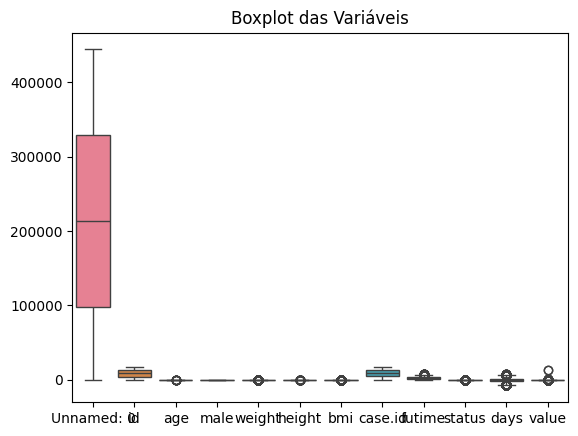

Valores Faltantes em cada coluna:
 Unnamed: 0         0
id                 0
age           400123
male          400123
weight        404909
height        403291
bmi           405084
case.id       400154
futime        400123
status        400123
days           17549
test           17549
value          17549
dtype: int64
Tipos de dados no dataframe:
 Unnamed: 0      int64
id              int64
age           float64
male          float64
weight        float64
height        float64
bmi           float64
case.id       float64
futime        float64
status        float64
days          float64
test           object
value         float64
dtype: object
Valores faltantes após a imputação de colunas numéricas:
 Unnamed: 0    0
id            0
age           0
male          0
weight        0
height        0
bmi           0
case.id       0
futime        0
status        0
days          0
value         0
dtype: int64
Valores faltantes no DataFrame final: 0
Valores faltantes no DataFrame final após esca

ValueError: Data must be 1-dimensional, got ndarray of shape (417672, 2) instead

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Carregar dados da camada Bronze
df_bronze1 = pd.read_parquet("../data/bronze/nafld1.parquet")
df_bronze2 = pd.read_parquet("../data/bronze/nafld2.parquet")

# Combinar os dois dataframes em um único dataframe para análise
df = pd.concat([df_bronze1, df_bronze2], axis=0)

# Análise Descritiva Avançada
print(df.describe())
sns.boxplot(data=df)
plt.title("Boxplot das Variáveis")
plt.show()

# Verificar Dados Faltantes e Tipos de Dados
missing_values = df.isnull().sum()
print("Valores Faltantes em cada coluna:\n", missing_values)
print("Tipos de dados no dataframe:\n", df.dtypes)

# Conversão de colunas booleanas para int (se necessário)
bool_columns = df.select_dtypes(include=['bool']).columns
df[bool_columns] = df[bool_columns].astype(int)

# Imputação de Valores Faltantes usando SimpleImputer para colunas numéricas
numeric_columns = df.select_dtypes(include=[float, int]).columns
imputer_num = SimpleImputer(strategy='mean')
df_imputed_num = pd.DataFrame(imputer_num.fit_transform(df[numeric_columns]), columns=numeric_columns)

# Verificar se a imputação foi aplicada corretamente
print("Valores faltantes após a imputação de colunas numéricas:\n", df_imputed_num.isnull().sum())

# Aplicar dummies para colunas categóricas e inteiras
df_categorical = df.select_dtypes(include=['object', 'int'])
df_categorical_dummies = pd.get_dummies(df_categorical)

# Resetar os índices antes de concatenar
df_imputed_num.reset_index(drop=True, inplace=True)
df_categorical_dummies.reset_index(drop=True, inplace=True)

# Combinar os dados imputados e categóricos
df_final = pd.concat([df_imputed_num, df_categorical_dummies], axis=1)

# Verificar se há valores faltantes no DataFrame final
missing_values_final = df_final.isnull().sum().sum()
print("Valores faltantes no DataFrame final:", missing_values_final)

# Transformações de Dados
scaler = StandardScaler()
df_final_scaled = pd.DataFrame(scaler.fit_transform(df_final), columns=df_final.columns)

# Verificar se há valores faltantes no DataFrame final após escala
missing_values_final_scaled = df_final_scaled.isnull().sum().sum()
print("Valores faltantes no DataFrame final após escala:", missing_values_final_scaled)

if missing_values_final_scaled == 0:
    # Análise de Agrupamento
    kmeans = KMeans(n_clusters=3)
    df_final_scaled['Cluster'] = kmeans.fit_predict(df_final_scaled)

    # Visualizações Detalhadas
    sns.pairplot(df_final_scaled, hue="Cluster")
    plt.title("Pairplot com Clusters")
    plt.show()

    # Salvar dados transformados na camada Silver
    df_final_scaled.to_parquet("../data/silver/nafld1.parquet")

    # Fazer upload dos arquivos Parquet para o bucket silver no MinIO
    from minio import Minio
    from minio.error import S3Error

    # Carregar variáveis de ambiente do .env
    import os
    from dotenv import load_dotenv
    load_dotenv()

    # Configurações do MinIO
    MINIO_ENDPOINT = os.getenv('MINIO_ENDPOINT')
    MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY')
    MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY')

    # Configurar o cliente MinIO
    client = Minio(
        MINIO_ENDPOINT,
        access_key=MINIO_ACCESS_KEY,
        secret_key=MINIO_SECRET_KEY,
        secure=False
    )

    # Nome do bucket
    silver_bucket = "silver"

    # Criar o bucket silver se não existir
    if not client.bucket_exists(silver_bucket):
        client.make_bucket(silver_bucket)

    # Fazer upload dos arquivos Parquet para o bucket silver no MinIO
    try:
        client.fput_object(
            silver_bucket, "nafld1.parquet", "../data/silver/nafld1.parquet"
        )
        print("Upload para o MinIO concluído com sucesso!")
    except S3Error as e:
        print(f"Erro ao fazer upload para o MinIO: {e}")
else:
    print("Ainda há valores faltantes no DataFrame final. O KMeans não pode ser aplicado.")